Imports and setup


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from random import randint
from math import pi as PI
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv("train.csv")

#We split the train data into train and validation datasets for self testing
dev_train_data = train_data.iloc[:len(train_data)//2]
dev_test_data = train_data.iloc[len(train_data)//2:]

# import warnings
# warnings.filterwarnings('ignore')

C:\Users\yoavr\AppData\Local\Temp\ipykernel_21324\2992628502.py:27: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv("train.csv")


In [71]:
# First - exploring and understanding the dataset, get familiar with the data
train_data.info()
train_data.describe()

categorical_features = [
    col for col in train_data.columns if train_data[col].dtype == "object"
]
numerical_features = [
    col for col in train_data.columns if train_data[col].dtype in ["int64", "float64"]
]

print("categorical features:", categorical_features)
print("numerical feat:", numerical_features)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293664 entries, 0 to 293663
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              293664 non-null  int64  
 1   agency                          277194 non-null  object 
 2   loan_type                       276278 non-null  object 
 3   property_type                   284403 non-null  object 
 4   loan_purpose                    274579 non-null  object 
 5   owner_occupancy                 275930 non-null  object 
 6   loan_amount                     279914 non-null  float64
 7   preapproval                     275159 non-null  object 
 8   msamd                           271610 non-null  object 
 9   county                          282393 non-null  object 
 10  county_code                     282754 non-null  float64
 11  census_tract_number             279167 non-null  float64
 12  applicant_ethnic

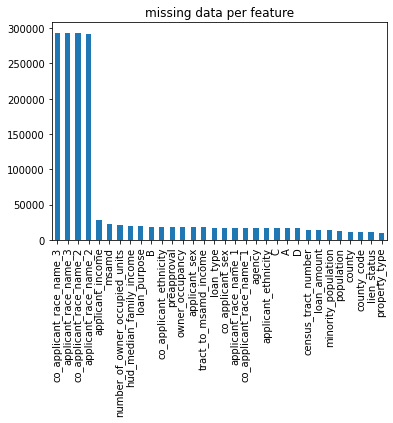

,Column Name,Number of Missing Values
0,co_applicant_race_name_3,293634
1,applicant_race_name_3,293508
2,co_applicant_race_name_2,293120
3,applicant_race_name_2,291685
4,applicant_income,27595
5,msamd,22054
6,number_of_owner_occupied_units,20814
7,hud_median_family_income,20034
8,loan_purpose,19085
9,B,18803


In [72]:
# looking for missing data

missing = train_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind="bar")
plt.title("missing data per feature")
plt.show()

missing_df = missing.reset_index()
missing_df.columns = ["Column Name", "Number of Missing Values"]
display(missing_df)

Visualisation


In [73]:
# שלב 1: סינון נתונים מספריים
# features = train_data.select_dtypes(include=['float64', 'int64'])

# שלב 2: הסרה של עמודת מטרה אם קיימת
# features = features.drop(columns=['target'], errors='ignore')

# שלב 3: נרמול
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(features)

# שלב 4: PCA
# pca = PCA(n_components=2)
# principal_components = pca.fit_transform(scaled_features)

# שלב 5: ויזואליזציה
# plt.figure(figsize=(8,6))
# plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.6)
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.title("PCA of train_data")
# plt.grid(True)
# plt.show()

In [74]:
# Histograms:
# for column in train_data.columns:
#   if column != "ID":
#     plt.figure(figsize=(8, 4))
#     if pd.api.types.is_numeric_dtype(train_data[column]):
#         plt.hist(train_data[column].dropna(), bins=20, edgecolor='black', color='skyblue')
#         plt.title(f"Histogram of {column}")
#         plt.xlabel(column)
#         plt.ylabel("Frequency")
#     else:
#         train_data[column].value_counts().plot(kind='bar', edgecolor='black', color='skyblue')
#         plt.title(f"Value Counts of {column}")
#         plt.xlabel(column)
#         plt.ylabel("Count")
#     plt.xticks(rotation=45, ha='right')
#     plt.tight_layout()
#     plt.show()

# CORRELATION


In [75]:
correlation = train_data["tract_to_msamd_income"].corr(train_data["applicant_income"])
print("Correlation:", correlation)

Correlation: 0.07858178611225242


In [76]:
train_data.columns = train_data.columns.str.strip()

numeric_df = train_data.select_dtypes(include=["float64", "int64"])

threshold = 0.6
for i, col1 in enumerate(numeric_df.columns):
    for j, col2 in enumerate(numeric_df.columns):
        if j > i:
            corr = numeric_df[col1].corr(numeric_df[col2])
            if abs(corr) > threshold:
                print(f"Correlation between '{col1}' and '{col2}': {corr:.3f}")

Correlation between 'population' and 'number_of_owner_occupied_units': 0.874
Correlation between 'population' and 'C': 0.878
Correlation between 'number_of_owner_occupied_units' and 'C': 0.949


After we found correlation - we want to see the vizualization


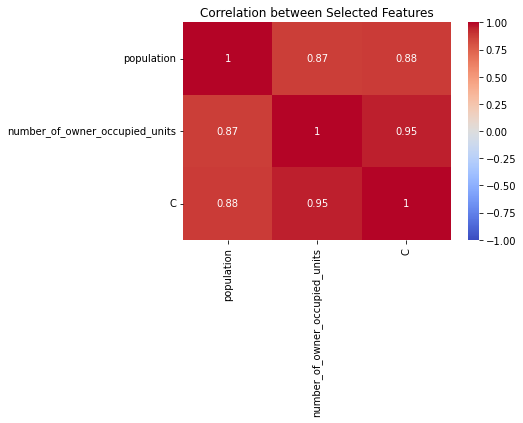

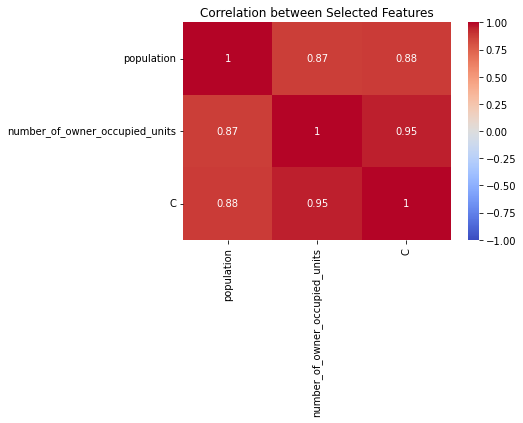

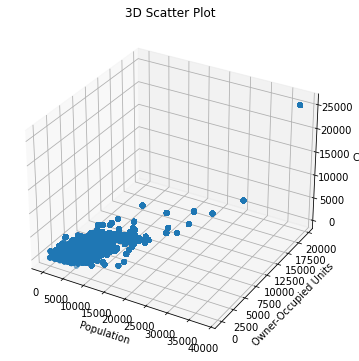

In [77]:
cols = ["population", "number_of_owner_occupied_units", "C"]
subset = train_data[cols]

subset.columns = subset.columns.str.strip()
corr_matrix = subset.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between Selected Features")
plt.show()

cols = ["population", "number_of_owner_occupied_units", "C"]
subset = train_data[cols]

subset.columns = subset.columns.str.strip()

corr_matrix = subset.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between Selected Features")
plt.show()


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    train_data["population"],
    train_data["number_of_owner_occupied_units"],
    train_data["C"],
    alpha=0.5,
)

ax.set_xlabel("Population")
ax.set_ylabel("Owner-Occupied Units")
ax.set_zlabel("C")
plt.title("3D Scatter Plot")
plt.show()

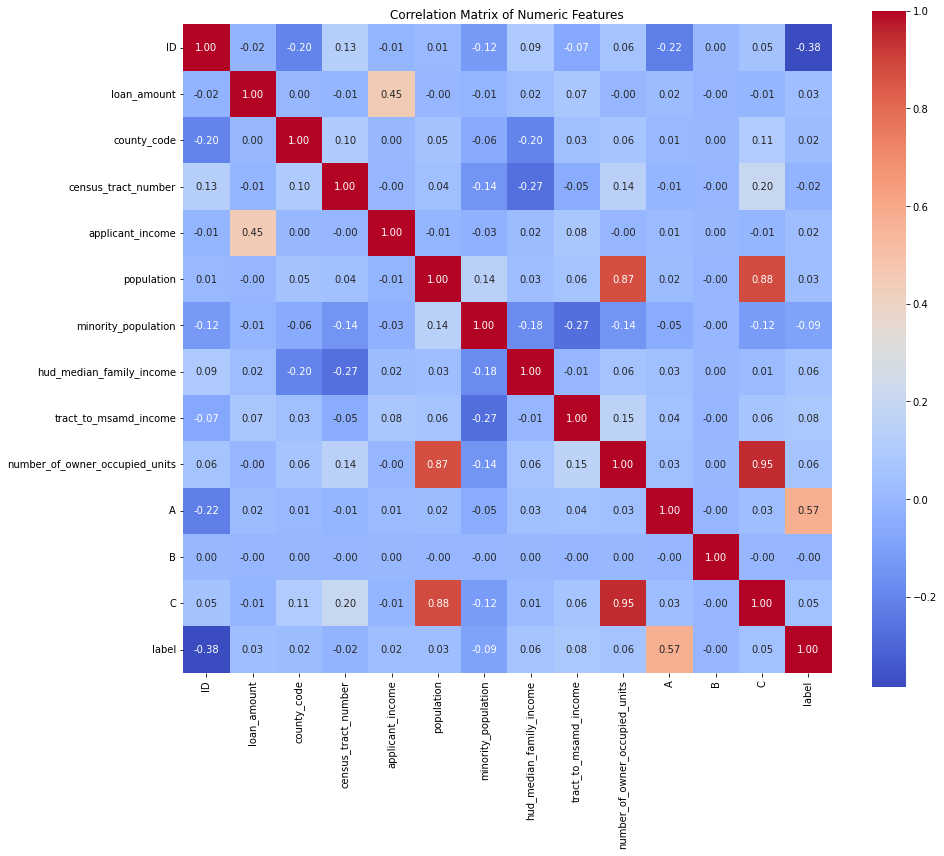

In [78]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [79]:
# Unifind same meaning features into a list:
def unify_to_list(df, features_list, unified_feature_name):
    df[unified_feature_name] = df[features_list].values.tolist()
    df[unified_feature_name] = df[unified_feature_name].apply(
        lambda row: sorted(set(str(s) for s in row if pd.notna(s)))
    )

# Dataframe manipulation
We use varius methods to manipulate the data to improve future results

In [ ]:
#Applying PCA to comine a list of features into a combined single feature
def apply_PCA(df, feature_list, combined_feature_name):
    features = df[feature_list]

    imputer = IterativeImputer(random_state=0)

    features_imputed = imputer.fit_transform(features)

    features_imputed_df = pd.DataFrame(features_imputed, columns=features.columns, index=features.index)

    scaled = StandardScaler().fit_transform(features_imputed_df)
    pca = PCA(n_components=1)
    principal_component = pca.fit_transform(scaled)

    df[combined_feature_name] = principal_component
    #print(train_data[['combined_feature']].head())
    #print(train_data['combined_feature'].isna().sum()) 

In [81]:
# Create a new column that combines applicant and co-applicant sex
def combine_sex(row):
    a = row.get("applicant_sex")
    c = row.get("co_applicant_sex")

    # If both are missing, return NaN
    if pd.isnull(a) and pd.isnull(c):
        return np.nan

    # If co-applicant is missing or marked as "No co-applicant", use only applicant
    if pd.isnull(c) or c == "No co-applicant":
        return a

    # If applicant is missing, use co-applicant
    if pd.isnull(a):
        return c

    # If both are the same, mark as "Both Male"/"Both Female"
    if a == c:
        return f"Both {a}"

    # If they are different, combine both
    return f"{a} + {c}"

In [82]:
# Create a new column that combines county and msamd into a single location group
def combine_location(row):
    county = row.get("county")
    msamd = row.get("msamd")

    if pd.isnull(county) and pd.isnull(msamd):
        return np.nan
    if pd.isnull(county):
        return msamd
    if pd.isnull(msamd):
        return county
    return f"{county} - {msamd}"

In [ ]:
def label_encoder(df, onehot_features): #return the preprocessor for future use   
    # Encode label
    le = LabelEncoder()
    df["label_encoded"] = le.fit_transform(df["label"])
    
    # Define which categorical features to use One-Hot vs Label Encoding
    onehot_features = ["owner_occupancy", "preapproval"]
    label_features = [
        col
        for col in df.columns
        if df[col].dtype == "object" and col not in onehot_features + ["label"]
    ]
    
    # Apply Label Encoding to the label_features
    for col in label_features:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # Define column transformer (only One-Hot features go through this)
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                onehot_features,
            )
        ],
        remainder="passthrough",
    )
    return preprocessor

In [84]:
# Unify races data to a single feature
def unify_races(df):
    unify_to_list(
    df,
    ["applicant_race_name_1", "applicant_race_name_2", "applicant_race_name_3"],
    "applicant_races",
)

In [85]:
# dev_train_data["applicant_races"].value_counts().plot(
#     kind="bar", edgecolor="black", color="skyblue"
# )

# plt.title("Value Counts of applicant_races")

# plt.xlabel("applicant_races")

# plt.ylabel("Count")

In [86]:
#We want a general function to get a df as an input and manipulate the data as we want (we wont work twice for train and test data)
def manipulate_df(df):
    #part 1: combining corrolating features using PCA
    apply_PCA(df, ['population', 'number_of_owner_occupied_units', 'C'] , 'combined_feature')

    #part 2: create a new column that combines applicant and co-applicant sex
    df["combined_sex"] = df.apply(combine_sex, axis=1)
    # Show example rows
    #train_data[["applicant_sex", "co_applicant_sex", "combined_sex"]].head(10)

    #part 3: Create a new column that combines county and msamd into a single location group
    df["location_group"] = df.apply(combine_location, axis=1)
    # Show example rows
    #df[["county", "msamd", "location_group"]].head(10)

    #part 4: Fix list-type cells in object columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)

    #part 5: unify races
    unify_races(df)

    #part 6: Label encoding
    preprocessor= label_encoder(df, ["owner_occupancy", "preapproval"])

    return preprocessor
    
    

# Models

In [87]:
#Apply our data manipulation on the train data:
preprocessor=manipulate_df(dev_train_data)

C:\Users\yoavr\AppData\Roaming\Python\Python310\site-packages\sklearn\impute\_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\yoavr\AppData\Local\Temp\ipykernel_21324\1321193138.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[combined_feature_name] = principal_component
C:\Users\yoavr\AppData\Local\Temp\ipykernel_21324\1926590515.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["combined_sex"] = df.apply(combine_sex, axis

RandomForest


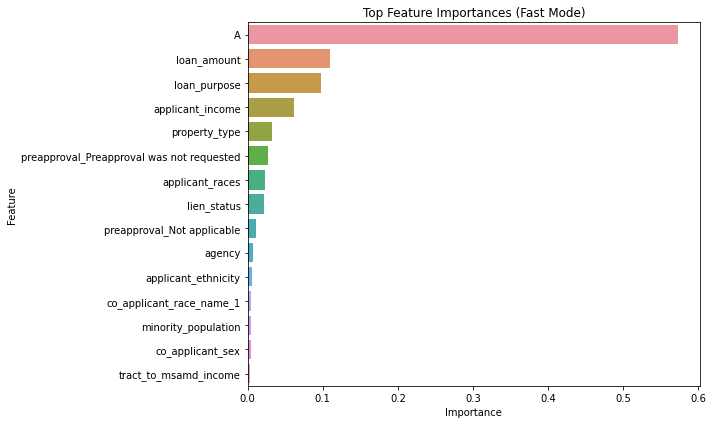

,Feature,Importance
0,A,0.573787
1,loan_amount,0.109420
2,loan_purpose,0.097767
3,applicant_income,0.061321
4,property_type,0.033006
5,preapproval_Preapproval was not requested,0.027164
6,applicant_races,0.022592
7,lien_status,0.022143
8,preapproval_Not applicable,0.010819
9,agency,0.006702


In [ ]:
#Applying Random Forest model
# Separate features and label
y = dev_train_data["label_encoded"]
X = dev_train_data.drop(
    columns=[
        "label",
        "label_encoded",
        "ID",  # Removing ID to prevent data leakage
        "population",  # Already merged into combined_feature
        "number_of_owner_occupied_units",  # Already merged into combined_feature
        "C",  # Already merged into combined_feature
        #    'applicant_sex',  #Combined into combined_sex
        #   'co_applicant_sex',  #Combined into combined_sex
        "county",  # Combined into location_group
        "msamd",  # Combined into location_group
        "applicant_race_name_1",  # Unified into applicant_races
        "applicant_race_name_2",  # Unified into applicant_races
        "applicant_race_name_3",  # Unified into applicant_races
    ]
)
# Use a smaller, faster model
pipeline = Pipeline(
    [
        ("preprocess", preprocessor),
        ("impute", SimpleImputer(strategy="median")),  # must be before scale
        ("scale", StandardScaler(with_mean=False)),
        ("clf", RandomForestClassifier(n_estimators=20, max_depth=6, random_state=0)),
    ]
)

# Fit the pipeline
X_transformed = pipeline.named_steps["preprocess"].fit_transform(X)
X_imputed = pipeline.named_steps["impute"].fit_transform(X_transformed)
X_scaled = pipeline.named_steps["scale"].fit_transform(X_imputed)
pipeline.named_steps["clf"].fit(X_scaled, y)

# Get feature names after encoding
onehot_features = ["owner_occupancy", "preapproval"]
encoded_columns = (
    pipeline.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(onehot_features)
)
other_columns = [col for col in X.columns if col not in onehot_features]
all_feature_names = list(encoded_columns) + other_columns

# Truncate in case of mismatches
min_len = min(
    len(all_feature_names), len(pipeline.named_steps["clf"].feature_importances_)
)

# Get feature importances
importances = pipeline.named_steps["clf"].feature_importances_[:min_len]
importance_df = (
    pd.DataFrame({"Feature": all_feature_names[:min_len], "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

# Plot top 15 only
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15))
plt.title("Top Feature Importances (Fast Mode)")
plt.tight_layout()
plt.show()

# Show top features
importance_df.head(20)

In [95]:
# Applying data manipulation on the test data
manipulate_df(dev_test_data)

# 5. הכנה לתחזית: שמירת אותן עמודות בדיוק כמו באימון
X_test = dev_test_data[X.columns]  # זה חייב להיות בדיוק אותן עמודות

# 6. תחזית בינארית
y_test_pred = pipeline.predict(X_test)

# 7. שמירת התחזית לקובץ CSV
results = pd.DataFrame({
    "ID": dev_test_data["ID"],
    "prediction": y_test_pred,  # 0 או 1
    "True result": dev_test_data["label_encoded"], 
})
#results.to_csv("loan_predictions.csv", index=False)

# Print results
print(results.head())
print("Model accuracy: " + str((y_test_pred == dev_test_data['label_encoded']).mean() * 100))


C:\Users\yoavr\AppData\Roaming\Python\Python310\site-packages\sklearn\impute\_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\yoavr\AppData\Local\Temp\ipykernel_21324\1321193138.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[combined_feature_name] = principal_component
C:\Users\yoavr\AppData\Local\Temp\ipykernel_21324\1926590515.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["combined_sex"] = df.apply(combine_sex, axis

            ID  prediction  True result
146832  311925           1            1
146833   32370           1            1
146834   93766           0            1
146835  111672           0            1
146836  554191           0            0
Model accuracy: 77.89174022011551
